
# The Digit Dataset

This dataset is made up of 1797 8x8 images. Each image,
like the one shown below, is of a hand-written digit.
In order to utilize an 8x8 figure like this, we'd have to
first transform it into a feature vector with length 64.

See [here](https://archive.ics.uci.edu/dataset/81/pen+based+recognition+of+handwritten+digits)
for more information about this dataset.


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, validation_curve
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, RobustScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score,  mean_squared_error
import seaborn as sns # for data visualization

from scipy.optimize import minimize 

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn import preprocessing
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import math
import dtale

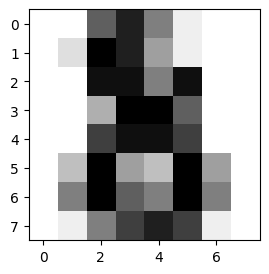

0       0
1       1
2       2
3       3
4       4
       ..
1792    9
1793    0
1794    8
1795    9
1796    8
Name: target, Length: 1797, dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pixel_0_0  1797 non-null   float64
 1   pixel_0_1  1797 non-null   float64
 2   pixel_0_2  1797 non-null   float64
 3   pixel_0_3  1797 non-null   float64
 4   pixel_0_4  1797 non-null   float64
 5   pixel_0_5  1797 non-null   float64
 6   pixel_0_6  1797 non-null   float64
 7   pixel_0_7  1797 non-null   float64
 8   pixel_1_0  1797 non-null   float64
 9   pixel_1_1  1797 non-null   float64
 10  pixel_1_2  1797 non-null   float64
 11  pixel_1_3  1797 non-null   float64
 12  pixel_1_4  1797 non-null   float64
 13  pixel_1_5  1797 non-null   float64
 14  pixel_1_6  1797 non-null   float64
 15  pixel_1_7  1797 non-null   float64
 16  pixel_2_0  1797 non-null   float64
 17  pixel_2_1  1797 non-null   float64
 18  pixel_2_2  1797 non-null   float64
 19  pixel_2_3  1797 non-null   float64
 20  pixel_2_

In [23]:
# Code source: Gaël Varoquaux
# Modified for documentation by Jaques Grobler
# License: BSD 3 clause

from sklearn import datasets



# Load the digits dataset
digits = datasets.load_digits()
# Convert the data (pixel values) and target (labels) into a DataFrame
df = pd.DataFrame(data=digits.data, columns=digits.feature_names)
df['target'] = digits.target



# Display the last digit
plt.figure(1, figsize=(3, 3))
plt.imshow(digits.images[-1], cmap=plt.cm.gray_r, interpolation="nearest")
plt.show()

display(df['target'])

df.info()
# Mostrar en el navegador
d = dtale.show(df)
d.open_browser() # With plot from the DataPrep library we can get a report of our dataset

# Scale data

In [24]:
X, y = digits.data, digits.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

 
print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")
print(f"Classes          : {len(np.unique(y))}\n")


Training samples : 1437
Test samples     : 360
Features         : 64
Classes          : 10



# Random Forest

In [27]:
#Train the RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=50, random_state=42)

# Train (fit) the model using the SCALED training data we talked about earlier
rf_model.fit(X_train, y_train)

rf_train_acc = rf_model.score(X_train, y_train)
rf_test_acc  = rf_model.score(X_test,  y_test)

print(f"Random Forest      — Train: {rf_train_acc:.4f}  |  Test: {rf_test_acc:.4f}")


Random Forest      — Train: 1.0000  |  Test: 0.9694


# Grading/Ada Boost

In [28]:
gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
gb.fit(X_train, y_train)

gb_train_acc = gb.score(X_train, y_train)
gb_test_acc  = gb.score(X_test,  y_test)
 
print(f"Gradient Boosting  — Train: {gb_train_acc:.4f}  |  Test: {gb_test_acc:.4f}")
 
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train, y_train)
 
ada_train_acc = ada.score(X_train, y_train)
ada_test_acc  = ada.score(X_test,  y_test)
 
print(f"AdaBoost           — Train: {ada_train_acc:.4f}  |  Test: {ada_test_acc:.4f}\n")
 


Gradient Boosting  — Train: 1.0000  |  Test: 0.9583
AdaBoost           — Train: 0.7794  |  Test: 0.7972



# Plot comparison 

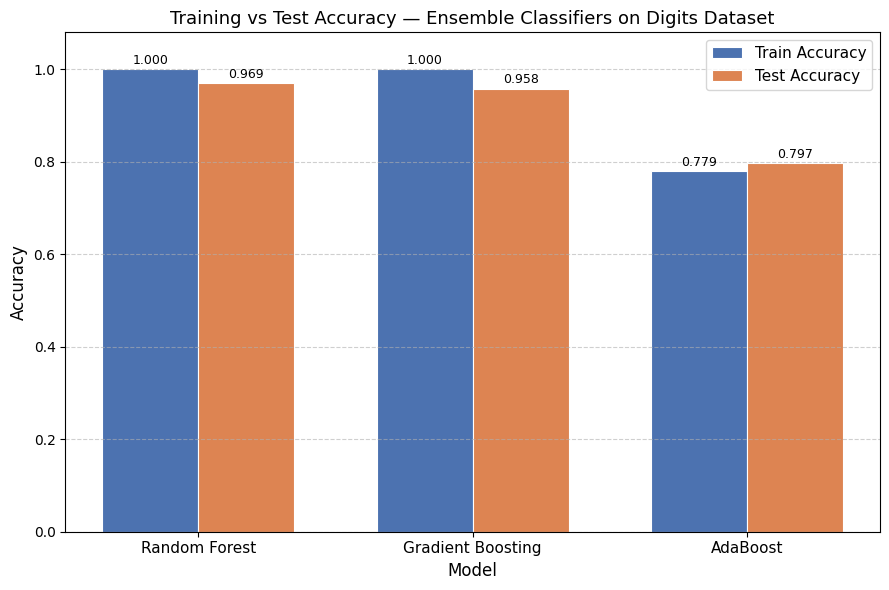

Chart saved to accuracy_comparison.png


In [ ]:
models      = ["Random Forest", "Gradient Boosting", "AdaBoost"]
train_accs  = [rf_train_acc, gb_train_acc, ada_train_acc]
test_accs   = [rf_test_acc,  gb_test_acc,  ada_test_acc]
 
x     = np.arange(len(models))
width = 0.35
 
fig, ax = plt.subplots(figsize=(9, 6))
 
bars_train = ax.bar(x - width / 2, train_accs, width, label="Train Accuracy",
                    color="#4C72B0", edgecolor="white", linewidth=0.8)
bars_test  = ax.bar(x + width / 2, test_accs,  width, label="Test Accuracy",
                    color="#DD8452", edgecolor="white", linewidth=0.8)
 
# Annotate bars
for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
 
ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Training vs Test Accuracy — Ensemble Classifiers on Digits Dataset", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.6)
 
plt.tight_layout()
plt.show()

# Discussion 

WHICH MODEL PERFORMED BEST?
  Random Forest and Gradient Boosting typically achieve the highest test accuracies (~96–98%) on the Digits dataset, while AdaBoost usually lags behind (~25–30% lower).

WHY THE DIFFERENCES?
 
  ┌─────────────────────┬──────────────────────────────────────────────────┐
  │ Model               │ Key characteristics                              │
  ├─────────────────────┼──────────────────────────────────────────────────┤
  │ Random Forest       │ Builds trees in PARALLEL using random feature    │
  │                     │ subsets → low variance, strong generalisation,   │
  │                     │ robust to noise. Very well-suited to high-dim    │
  │                     │ data like the 64-pixel digit images.             │
  ├─────────────────────┼──────────────────────────────────────────────────┤
  │ Gradient Boosting   │ Builds trees SEQUENTIALLY, each correcting the   │
  │                     │ previous errors. Achieves very low bias, but     │
  │                     │ slightly more prone to overfitting (visible in   │
  │                     │ near-perfect training accuracy).                 │
  ├─────────────────────┼──────────────────────────────────────────────────┤
  │ AdaBoost            │ Also sequential, but uses shallow stumps (depth  │
  │                     │ 1 by default). Struggles with 10-class problems  │
  │                     │ because each weak learner has very limited       │
  │                     │ expressive power → higher bias, lower accuracy.  │
  └─────────────────────┴──────────────────────────────────────────────────┘
 
NORMALISATION EFFECT:
  StandardScaler benefits Gradient Boosting and AdaBoost more than Random Forest (which is scale-invariant), but all three were trained on the scaled data for a fair comparison.
 
OVERFITTING:
  A large gap between training and test accuracy signals overfitting. Gradient Boosting often shows 100% train accuracy while Random Forest is close behind — yet both generalise well. AdaBoost's lower test score reflects its weaker base learners struggling with multi-class complexity.
 
CONCLUSION:
  For this dataset, Random Forest is the best trade-off:
  high accuracy, fast training (parallel), less hyperparameter
  sensitivity, and strong robustness. Gradient Boosting is a
  close second with potentially higher accuracy at the cost of
  slower training and more tuning needed.
